In [43]:
# Imports
from math import log
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import sklearn.metrics as metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr
from matplotlib import pyplot as plt
from google.colab import userdata
from google.colab import files
from scipy import sparse
import seaborn as sns

## Preprocess Data

Extract & Clean Data

In [2]:
# import the data
df = pd.read_csv("nyc_ems_2023_2024_data.txt",
                 parse_dates=['incident_datetime', 'first_on_scene_datetime'])

In [3]:
# View df info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1853863 entries, 0 to 1853862
Data columns (total 16 columns):
 #   Column                         Dtype         
---  ------                         -----         
 0   cad_incident_id                int64         
 1   incident_datetime              datetime64[ns]
 2   initial_call_type              object        
 3   initial_severity_level_code    int64         
 4   final_call_type                object        
 5   final_severity_level_code      int64         
 6   first_assignment_datetime      object        
 7   dispatch_response_seconds_qy   int64         
 8   first_on_scene_datetime        datetime64[ns]
 9   incident_response_seconds_qy   float64       
 10  incident_travel_tm_seconds_qy  float64       
 11  incident_close_datetime        object        
 12  borough                        object        
 13  incident_dispatch_area         object        
 14  zipcode                        float64       
 15  special_event_i

In [4]:
# Drop rows where 'response_time_seconds' (the target variable) is NaN
df['response_time_seconds'] = (df['first_on_scene_datetime'] - df['incident_datetime']).dt.total_seconds()
df.dropna(subset=['response_time_seconds'], inplace=True)

Feature Engineering

In [5]:
# Define a meaningful hour colum --> incident_hour (0-23)
df['incident_hour'] = df['incident_datetime'].dt.hour

# Define a meaningful day column --> incident_day_of_week (0-6)
df['incident_day_of_week'] = df['incident_datetime'].dt.dayofweek

# Define a meaningful month column --> incident_month (1-12)
df['incident_month'] = df['incident_datetime'].dt.month

In [6]:
# Indicate whether an incident occurs on a weekend
df['is_weekend'] = df['incident_day_of_week'].isin([5, 6]).astype(int)

# Indicate whether an incident occurs during rush hour
is_weekday = ~df['incident_day_of_week'].isin([5, 6])
is_morning_rush = (df['incident_hour'] >= 6) & (df['incident_hour'] <= 10)          # morning rush: 6-10AM
is_evening_rush = (df['incident_hour'] >= 16) & (df['incident_hour'] <= 20)         # evening rush: 4-8PM
df['is_rush_hour'] = ((is_morning_rush | is_evening_rush) & is_weekday).astype(int) # binary categorical

# Turn special_event_indicator into a binary numerical categorical variable
df['special_event_indicator'] = df['special_event_indicator'].map({'Y': 1, 'N': 0}).fillna(0).astype(int)

Lag & Rolling Features

In [7]:
# Create a lag feature: response time of previous incident in the same service area
df['lag_response_time'] = df.groupby('incident_dispatch_area')['response_time_seconds'].shift(1)

# For rows that don't have a previous response time, impute with overall mean response time
avg_response_time = df['response_time_seconds'].mean()
df['lag_response_time'] = df['lag_response_time'].fillna(avg_response_time)

In [8]:
# Ensure chronological order before calculating rolling avg
df = df.sort_values(by='incident_datetime').reset_index(drop=True)

# Create a rolling avg. response time feature for the past 3 hours
df['rolling_avg_response_time_3h'] = (df
    .groupby('incident_dispatch_area', observed=True)            # group by dispatch area
    [['incident_datetime', 'response_time_seconds']]             # select both columns
    .rolling(window='3h', on='incident_datetime', closed='left') # 3hr window <-- we can change this to a different value too
    .mean()                                                      # calculate avg
    ['response_time_seconds'] # use the response_time_seconds column from the result
    .reset_index(level=0, drop=True)
)

# For rows that don't have 3hr of previous data, impute with overall mean response time
df['rolling_avg_response_time_3h'] = df['rolling_avg_response_time_3h'].fillna(avg_response_time)

In [9]:
# Create a lagged incident count feature for the past 15 minutes
df['lag_incident_count_15min'] = (df
    .groupby('incident_dispatch_area', observed=True)               # group by dispatch are
    .rolling(window='15min', on='incident_datetime', closed='left') # 15min window <-- we can change this to a different value too
    .count()                                                        # calculate total count
    ['cad_incident_id'] # use the count for cad_incident_id (ensures integer type)
    .reset_index(level=0, drop=True)
)

# For rows that don't have any incidents within the last 15min - impute NaN with 0 and ensure integer type
df['lag_incident_count_15min'] = df['lag_incident_count_15min'].fillna(0).astype(int)

In [10]:
# View df info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1853862 entries, 0 to 1853861
Data columns (total 25 columns):
 #   Column                         Dtype         
---  ------                         -----         
 0   cad_incident_id                int64         
 1   incident_datetime              datetime64[ns]
 2   initial_call_type              object        
 3   initial_severity_level_code    int64         
 4   final_call_type                object        
 5   final_severity_level_code      int64         
 6   first_assignment_datetime      object        
 7   dispatch_response_seconds_qy   int64         
 8   first_on_scene_datetime        datetime64[ns]
 9   incident_response_seconds_qy   float64       
 10  incident_travel_tm_seconds_qy  float64       
 11  incident_close_datetime        object        
 12  borough                        object        
 13  incident_dispatch_area         object        
 14  zipcode                        float64       
 15  special_event_i

## Baseline Model

In [11]:
# Define target variable
target_variable_df = df[['incident_travel_tm_seconds_qy']]

# Define numerical and categorical features
numerical_features = [
    'initial_severity_level_code',
    'final_severity_level_code',
    'lag_response_time',
    'rolling_avg_response_time_3h',
    'lag_incident_count_15min'
]

# Binary numeric features (no one-hot encoding needed)
binary_numeric_features = [
    'special_event_indicator',
    'is_weekend',
    'is_rush_hour'
]

# Features we need to one-hot encode
categorical_features = [
    'borough',
    'incident_dispatch_area',
    'incident_hour',
    'incident_day_of_week',
    'incident_month'
]

In [12]:
# Combine all selected features
all_features = numerical_features + binary_numeric_features + categorical_features
features_df = df[all_features].copy()

# Update features_columns and target_variable_columns for clarity
features_columns = all_features
target_variable_columns = list(target_variable_df.columns)

Split, scale, encode data

In [13]:
# Split the data into 80% train and 20% "holder data"
x_train_raw, x_main_raw, y_train, y_main = train_test_split(features_df, target_variable_df, test_size=0.20, random_state=42)

# Split the "holder data" into 10% for test and 10% validation
x_val_raw, x_test_raw, y_val, y_test = train_test_split(x_main_raw, y_main, test_size=0.50, random_state=42)

In [14]:
# Manual Scaling for Numerical Features (using raw data as there are no NaNs)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_raw[numerical_features])
x_val_scaled = scaler.transform(x_val_raw[numerical_features])
x_test_scaled = scaler.transform(x_test_raw[numerical_features])

In [15]:
# Manual One-Hot Encoding for Categorical Features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output = True)
x_train_encoded = encoder.fit_transform(x_train_raw[categorical_features])
x_val_encoded = encoder.transform(x_val_raw[categorical_features])
x_test_encoded = encoder.transform(x_test_raw[categorical_features])

In [16]:
# Concatenate processed numerical and categorical features
x_train_processed = np.hstack((x_train_scaled, x_train_encoded.toarray()))
x_val_processed = np.hstack((x_val_scaled, x_val_encoded.toarray()))
x_test_processed = np.hstack((x_test_scaled, x_test_encoded.toarray()))

# Printing of shapes for validation
print (f"Training: Features' shape =  {x_train_processed.shape}")
print (f"Training: Label's shape = {y_train.shape}")

print (f"Validation: Features' shape =  {x_val_processed.shape}")
print (f"Validation: Label's shape = {y_val.shape}")

print (f"Test: Features' shape =  {x_test_processed.shape}")
print (f"Test: Label's shape = {y_test.shape}")

Training: Features' shape =  (1483089, 88)
Training: Label's shape = (1483089, 1)
Validation: Features' shape =  (185386, 88)
Validation: Label's shape = (185386, 1)
Test: Features' shape =  (185387, 88)
Test: Label's shape = (185387, 1)


Linear Regression Baseline

In [17]:
# Train Linear Regression model
regression_model = LinearRegression()

# Training
regression = regression_model.fit(x_train_processed, y_train.to_numpy().flatten())
print ("Training complete")

Training complete


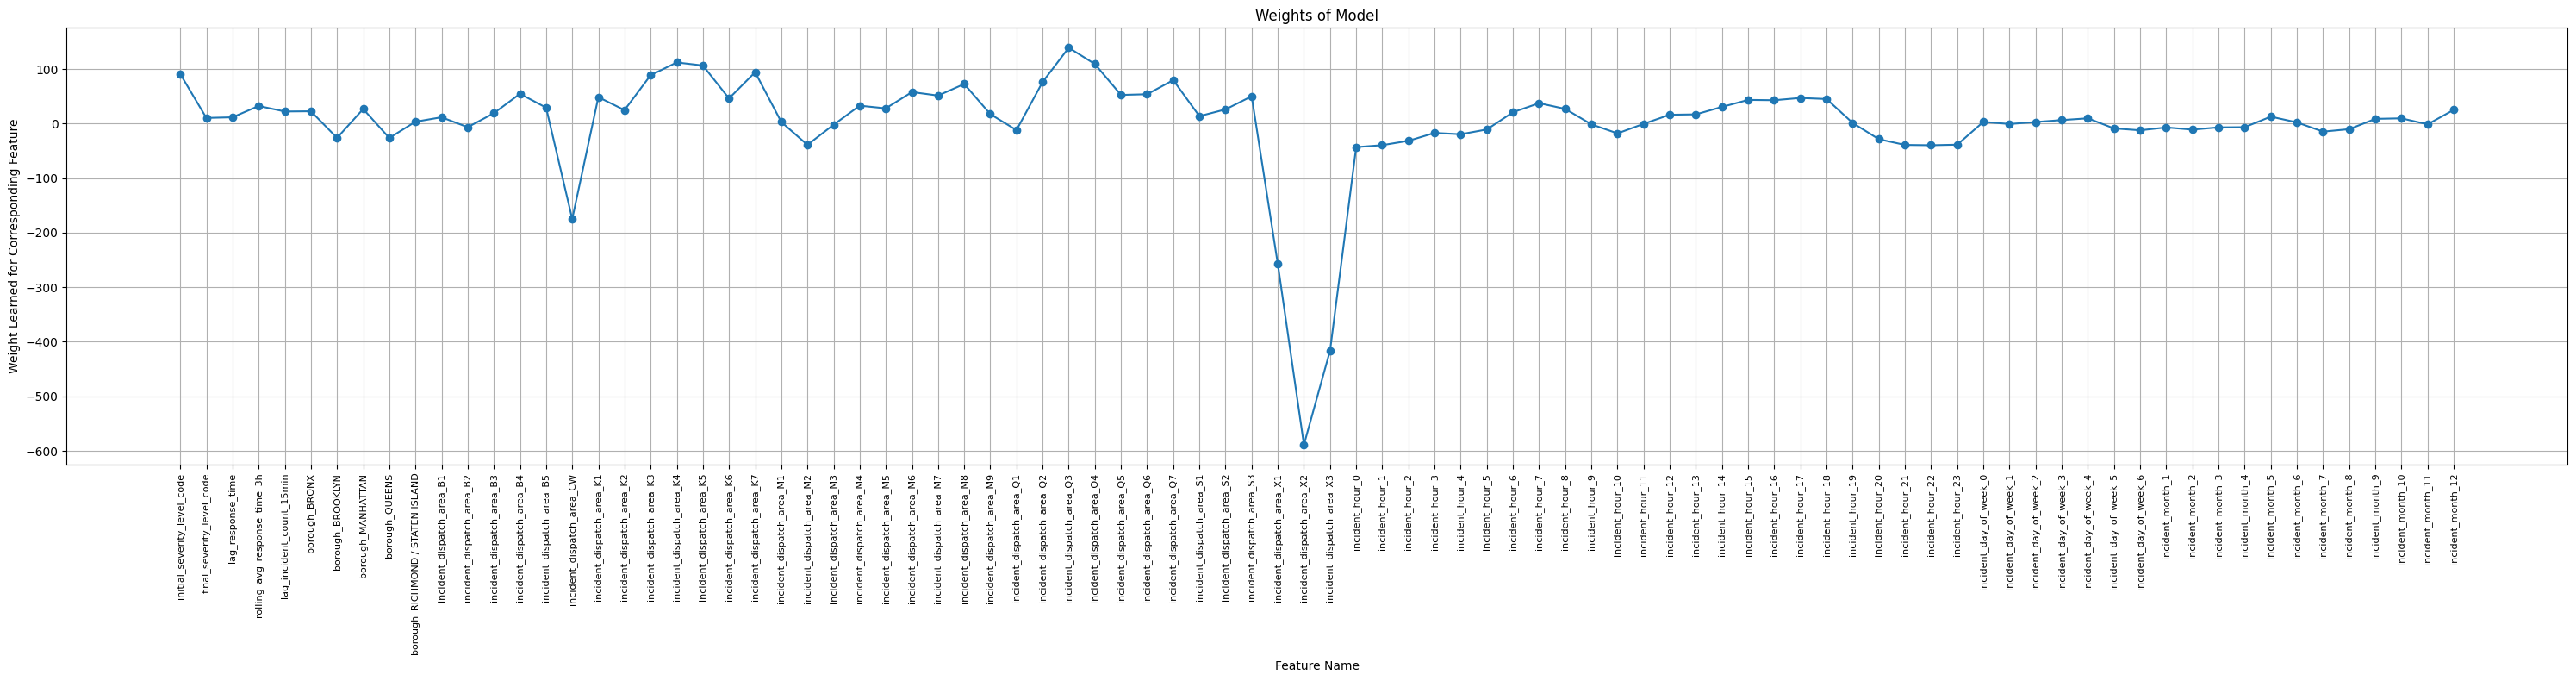

In [18]:
# Retriving the weights from the model
weights = regression_model.coef_

# Get feature names after one-hot encoding from the fitted encoder
# The order of features will be numerical features first, then one-hot encoded categorical features.
feature_names_out = numerical_features + list(encoder.get_feature_names_out(categorical_features))

# Ploting all the weights into a plot
plt.figure(figsize=(30,8)) # Increase figure size to accommodate more labels
plt.plot(range(len(weights)), weights, marker='o')
plt.xticks(range(len(weights)), feature_names_out, rotation=90, fontsize=8) # Rotate labels and adjust font size
plt.title('Weights of Model')
plt.xlabel("Feature Name")
plt.ylabel("Weight Learned for Corresponding Feature")
plt.grid(True)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [21]:
# Perform prediction on test data
y_test_predicted = regression_model.predict(x_test_processed)

# Calcuatling prefomance meterics
r2_baseline = metrics.r2_score(y_test, y_test_predicted)
mae_baseline=metrics.mean_absolute_error(y_test, y_test_predicted)
mse = metrics.mean_squared_error(y_test, y_test_predicted)
rmse_baseline = np.sqrt(mse)

# Printing the meterics
print (f"Linear Regressor: Mean Squared Error = {r2_baseline:.3f}")
print (f"Linear Regressor: Mean Absolute Error = {mae_baseline:.3f}")
print(f"Linear Regressor: Root Mean Square Error = {rmse_baseline:.3f}")

Linear Regressor: Mean Squared Error = 0.132
Linear Regressor: Mean Absolute Error = 212.767
Linear Regressor: Root Mean Square Error = 310.040


Ridge Variation

In [24]:
# Instantiate a Ridge regression model
ridge_model = Ridge(alpha=100.0)

# Fit the  model to the training data
ridge_model.fit(x_train_processed, y_train.to_numpy().flatten())

# Use the trained Ridge model to make predictions on the test data
y_test_predicted_ridge = ridge_model.predict(x_test_processed)

# Calcuatling prefomance meterics
r2_ridge = metrics.r2_score(y_test, y_test_predicted_ridge)
mae_ridge=metrics.mean_absolute_error(y_test, y_test_predicted_ridge)
mse_ridge = metrics.mean_squared_error(y_test, y_test_predicted_ridge)
rmse_ridge = np.sqrt(mse_ridge)

# 7. Print the calculated metrics
print(f"\nRidge Regressor: R^2 = {r2_ridge:.3f}")
print(f"Ridge Regressor: Mean Absolute Error = {mae_ridge:.3f}")
print(f"Ridge Regressor: Root Mean Square Error = {rmse_ridge:.3f}")


Ridge Regressor: R^2 = 0.132
Ridge Regressor: Mean Absolute Error = 212.766
Ridge Regressor: Root Mean Square Error = 310.045


Tranfomations Evalutions from Ploting of Variables

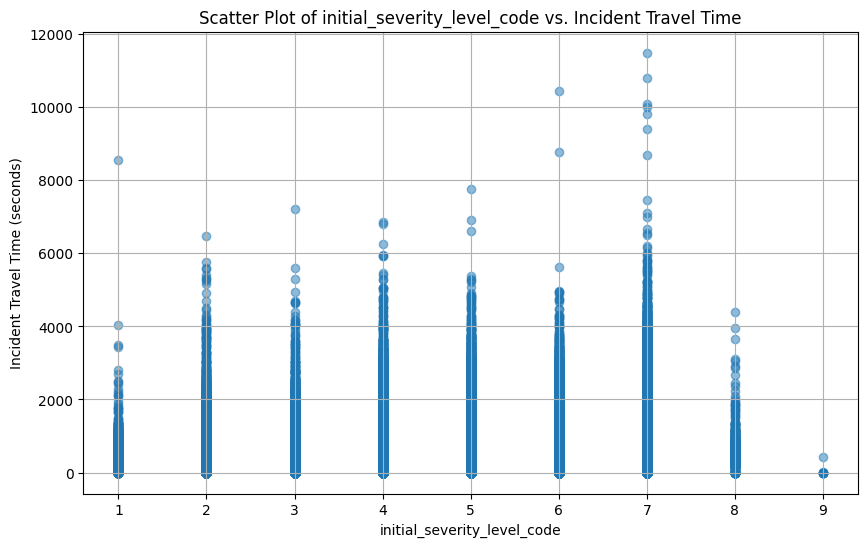

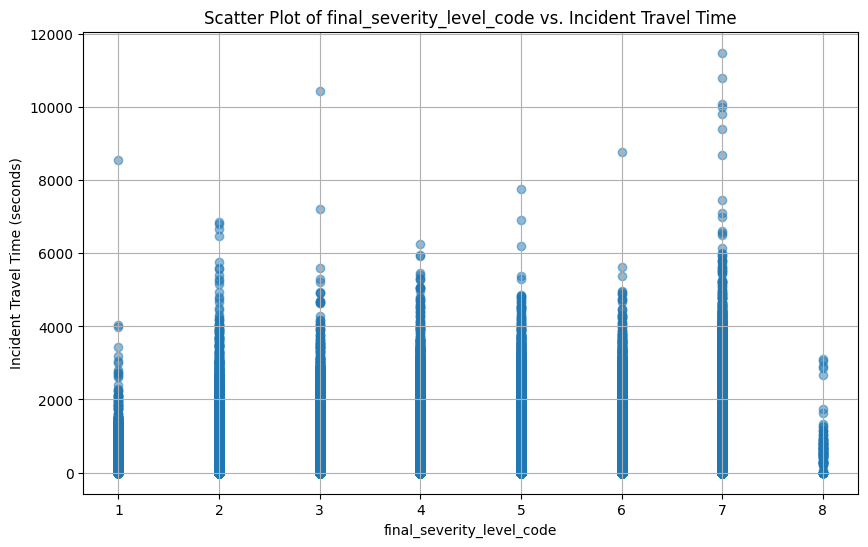

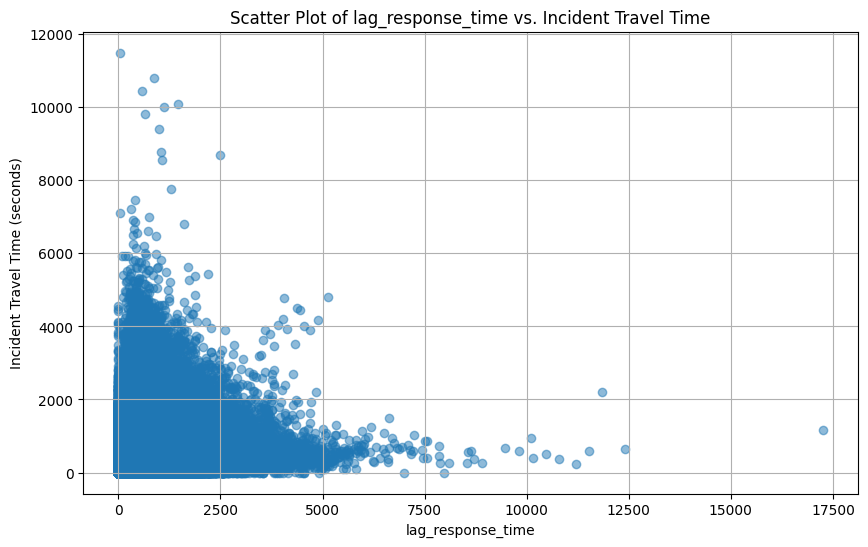

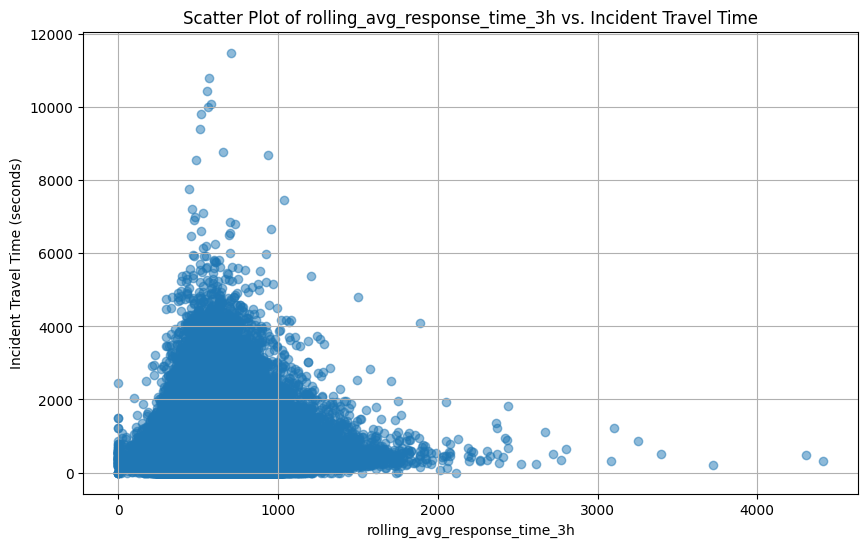

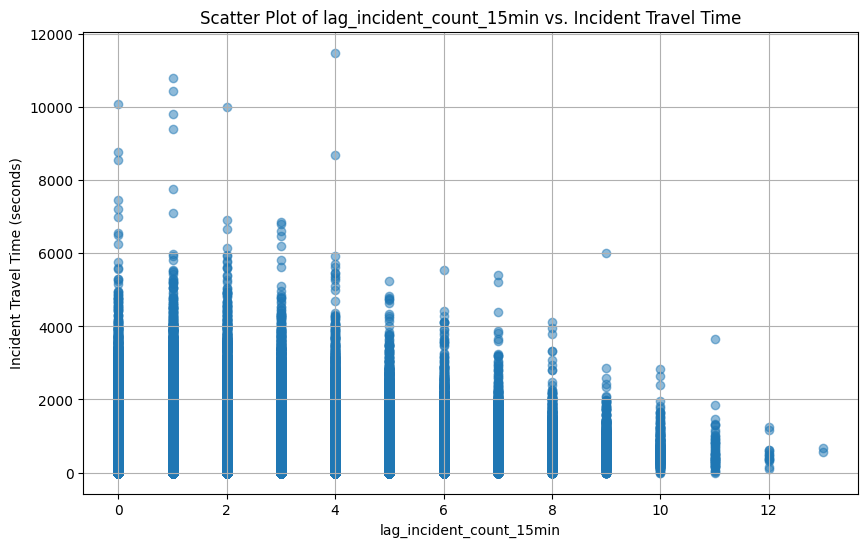

In [46]:
# Define the target variable name
target_variable_name = 'incident_travel_tm_seconds_qy'

# Iterate through each numerical feature and create a scatter plot
for feature in numerical_features:
    plt.figure(figsize=(10, 6))
    plt.scatter(df[feature], df[target_variable_name], alpha=0.5)
    plt.title(f'Scatter Plot of {feature} vs. Incident Travel Time')
    plt.xlabel(feature)
    plt.ylabel('Incident Travel Time (seconds)')
    plt.grid(True)
    plt.show()

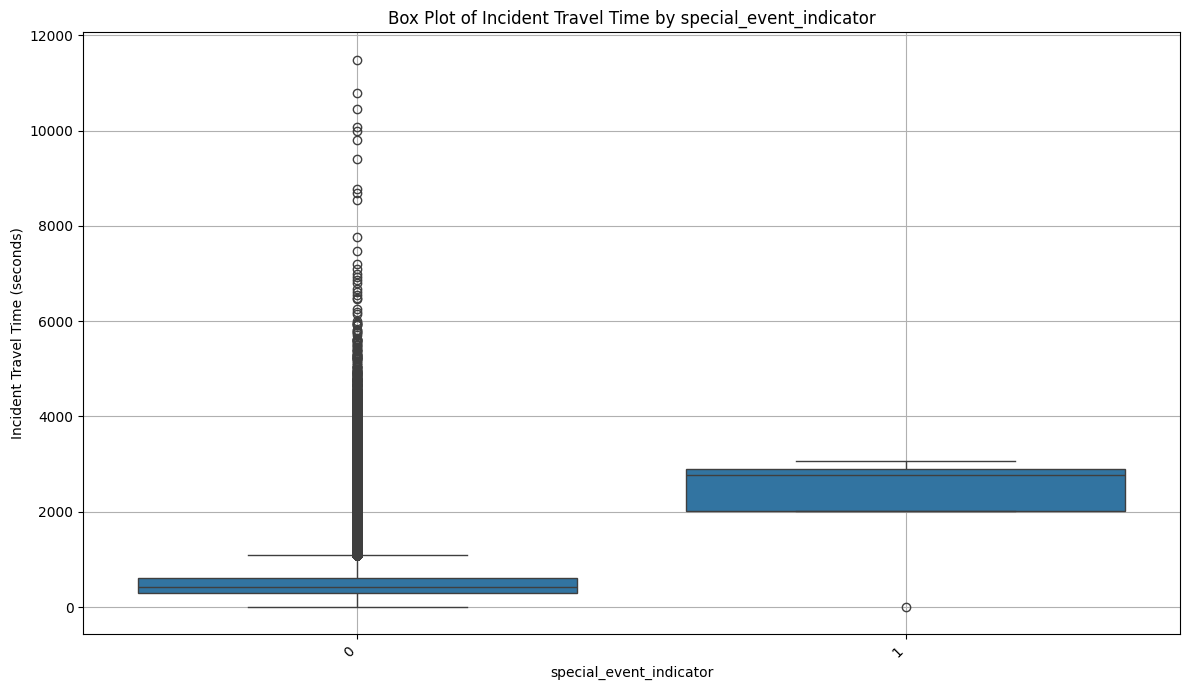

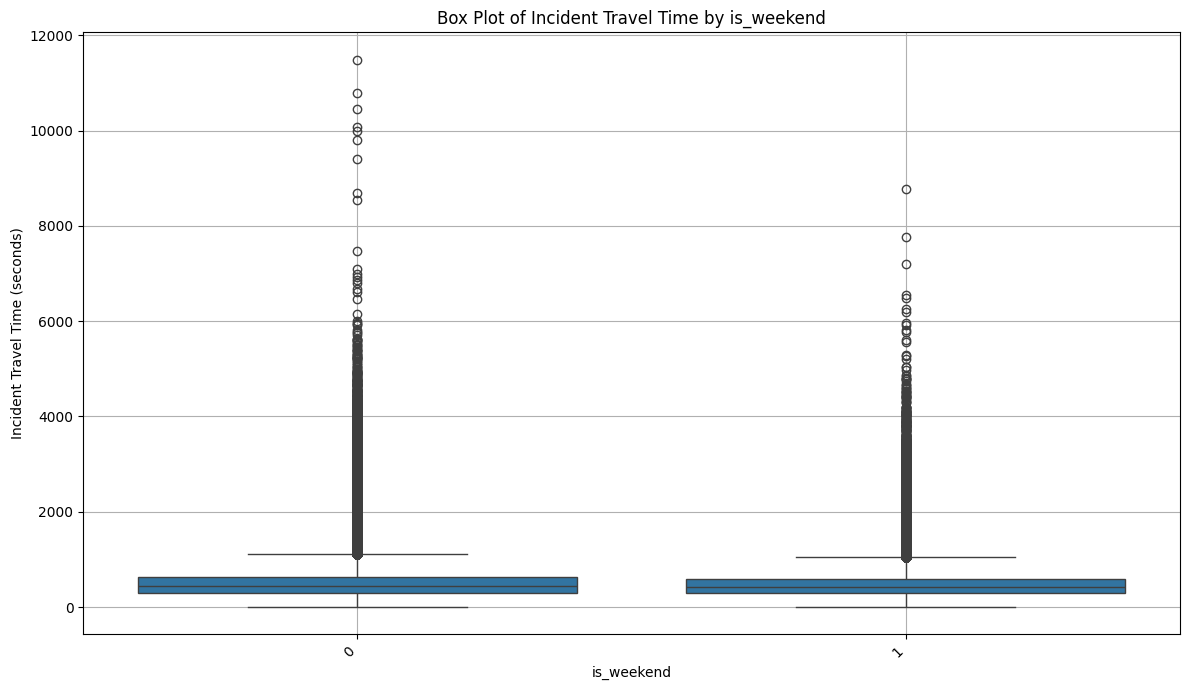

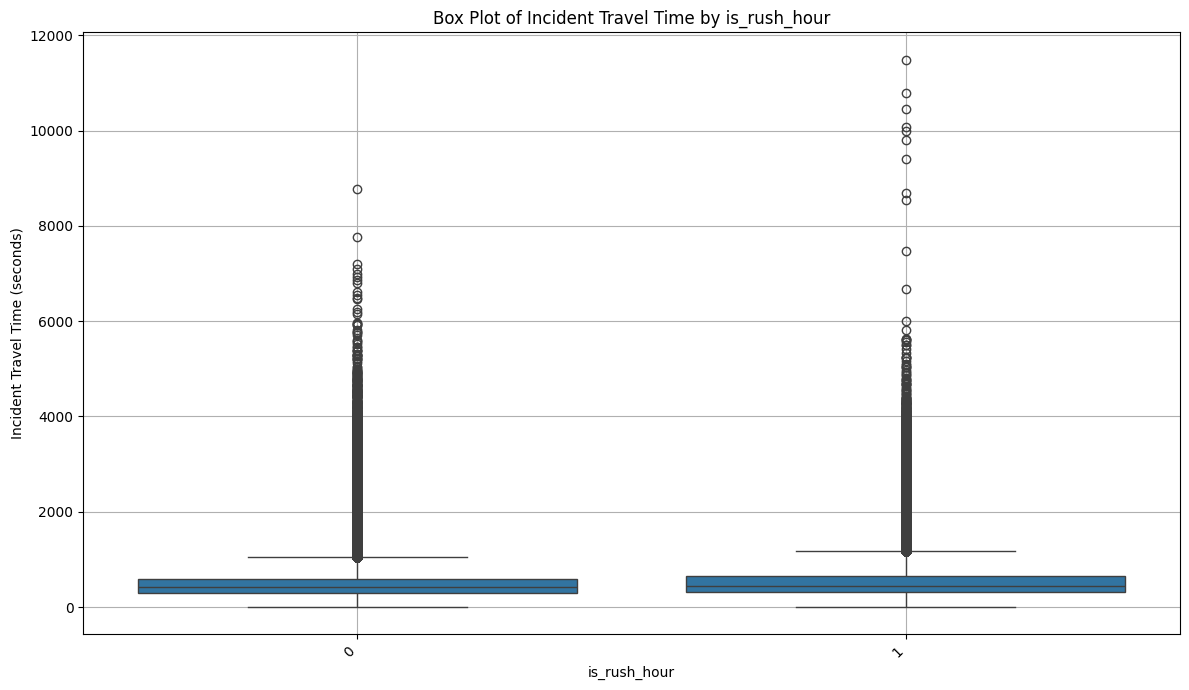

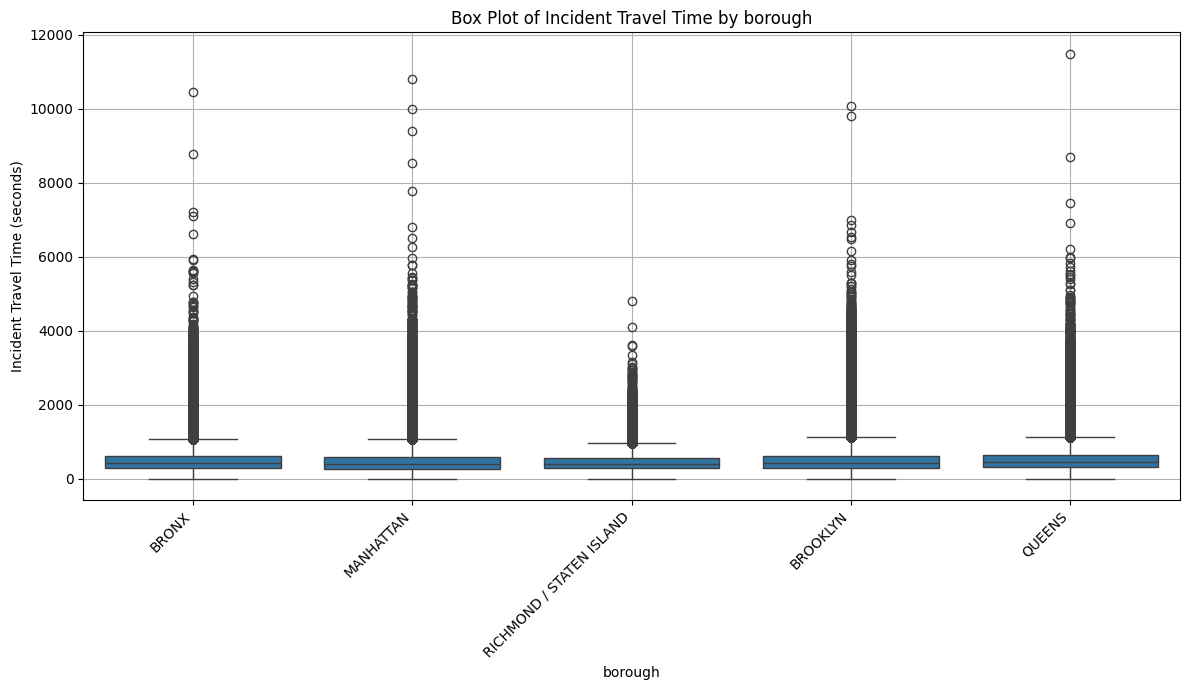

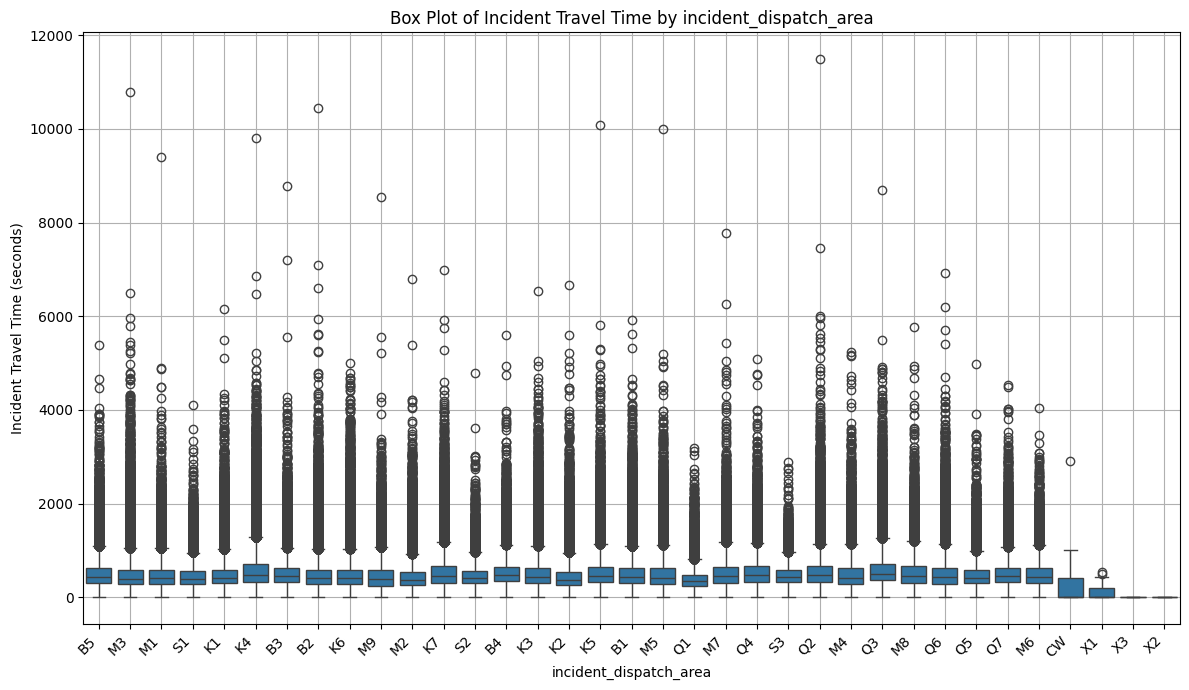

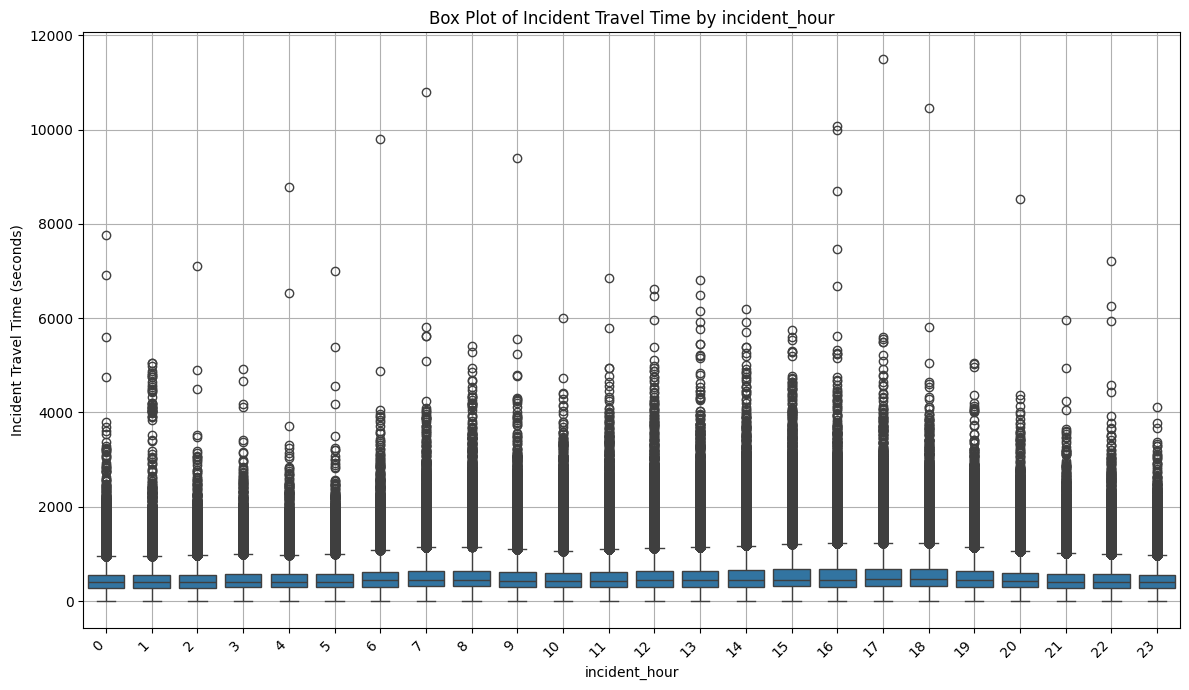

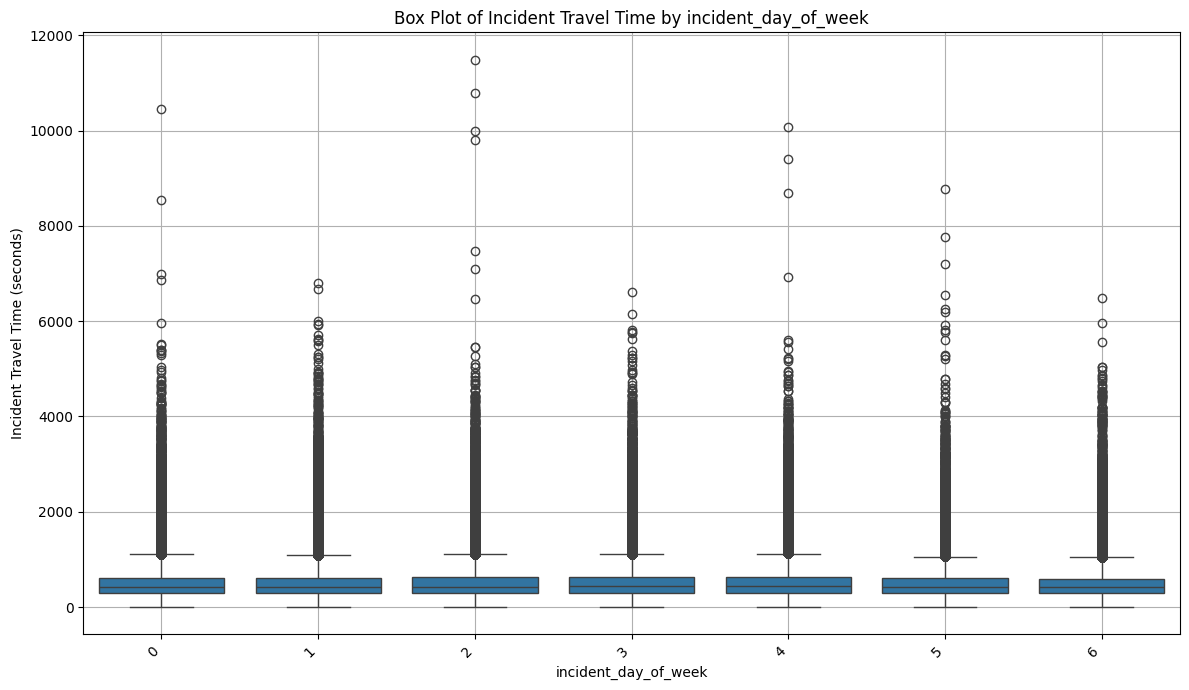

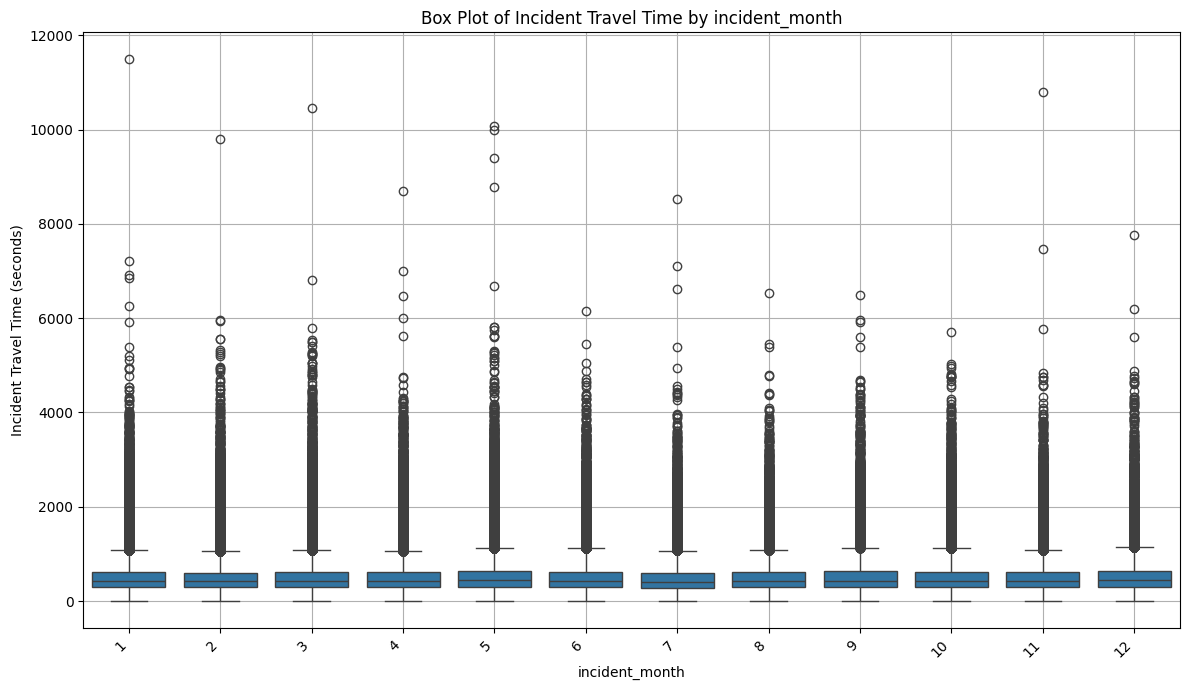

In [44]:
# Define the target variable name
target_variable_name = 'incident_travel_tm_seconds_qy'

# Iterate through each binary numeric and categorical feature and create a box plot
# Combine binary numeric features and categorical features for this visualization
combined_features = binary_numeric_features + categorical_features

for feature in combined_features:
    plt.figure(figsize=(12, 7))
    sns.boxplot(x=df[feature], y=df[target_variable_name])
    plt.title(f'Box Plot of Incident Travel Time by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Incident Travel Time (seconds)')
    plt.grid(True)
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
    plt.tight_layout() # Adjust layout to prevent labels from being cut off
    plt.show()

/tmp/ipython-input-3199632921.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y=target_variable_name, data=mean_travel_time, palette='viridis')


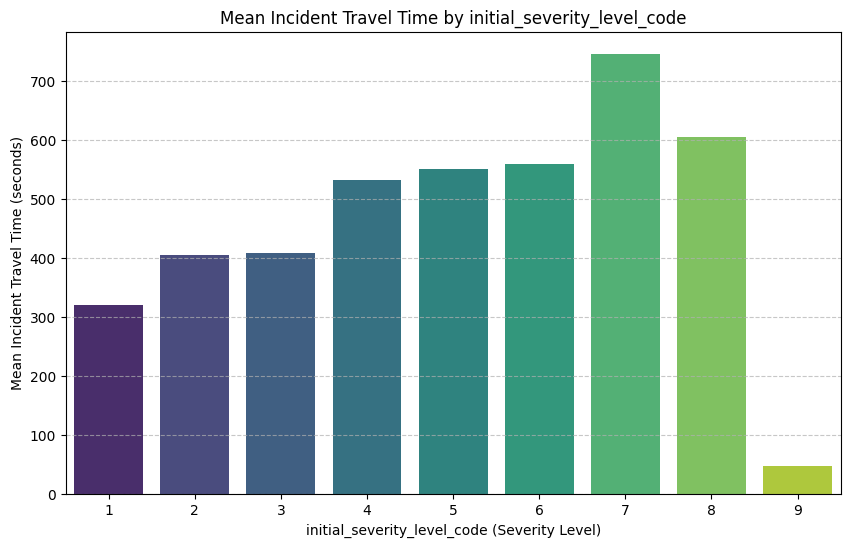

/tmp/ipython-input-3199632921.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y=target_variable_name, data=mean_travel_time, palette='viridis')


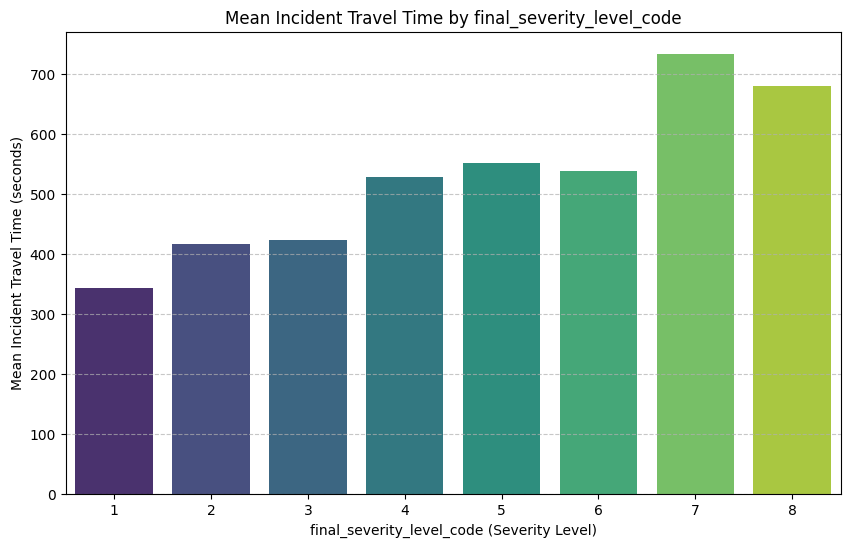

In [45]:
# Define the target variable name
target_variable_name = 'incident_travel_tm_seconds_qy'

# Features to visualize with bar plots
severity_features = ['initial_severity_level_code', 'final_severity_level_code']

for feature in severity_features:
    # Calculate the mean target variable for each category
    mean_travel_time = df.groupby(feature)[target_variable_name].mean().reset_index()

    plt.figure(figsize=(10, 6))
    sns.barplot(x=feature, y=target_variable_name, data=mean_travel_time, palette='viridis')
    plt.title(f'Mean Incident Travel Time by {feature}')
    plt.xlabel(f'{feature} (Severity Level)')
    plt.ylabel('Mean Incident Travel Time (seconds)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

Log Variant

In [25]:
# Apply np.log1p to y_train, y_val, and y_test
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_test_log = np.log1p(y_test)

# nstantiate a LinearRegression model
regression_model_log = LinearRegression()

# Fit the LinearRegression model using x_train_processed and y_train_log
regression_log = regression_model_log.fit(x_train_processed, y_train_log.to_numpy().flatten())
print("Linear Regression model trained with log-transformed target.")

# Make predictions on x_test_processed
y_test_predicted_log_transformed = regression_model_log.predict(x_test_processed)

# Apply np.expm1 to inverse transform the predictions
y_test_predicted_log_inverse_transformed = np.expm1(y_test_predicted_log_transformed)

# Calcuatling prefomance meterics
r2_log = metrics.r2_score(y_test, y_test_predicted_log_inverse_transformed)
mae_log=metrics.mean_absolute_error(y_test, y_test_predicted_log_inverse_transformed)
mse_log = metrics.mean_squared_error(y_test, y_test_predicted_log_inverse_transformed)
rmse_log = np.sqrt(mse_log)

# 7. Print the calculated metrics
print(f"\nLinear Regressor (Log-Transformed Target): R^2 = {r2_log:.3f}")
print(f"Linear Regressor (Log-Transformed Target): Mean Absolute Error = {mae_log:.3f}")
print(f"Linear Regressor (Log-Transformed Target): Root Mean Square Error = {rmse_log:.3f}")

Linear Regression model trained with log-transformed target.

Linear Regressor (Log-Transformed Target): R^2 = 0.033
Linear Regressor (Log-Transformed Target): Mean Absolute Error = 208.562
Linear Regressor (Log-Transformed Target): Root Mean Square Error = 327.242


Without Outliers

Q1 (25th percentile): 297.00
Q3 (75th percentile): 616.00
IQR: 319.00
Lower Bound for Outliers: -181.50
Upper Bound for Outliers: 1094.50


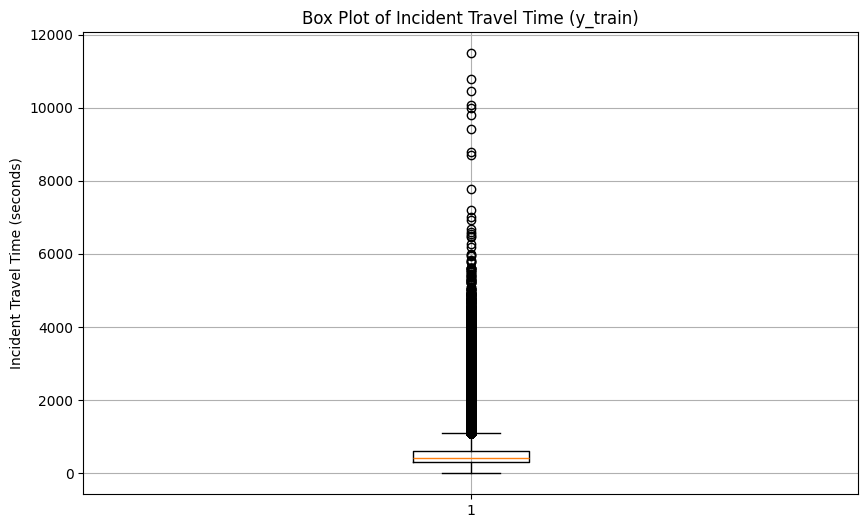

In [26]:
# Calculate Q1 and Q3
Q1 = y_train['incident_travel_tm_seconds_qy'].quantile(0.25)
Q3 = y_train['incident_travel_tm_seconds_qy'].quantile(0.75)

# Compute the Interquartile Range (IQR)
IQR = Q3 - Q1

# Determine the lower bound for outlier detection
lower_bound = Q1 - 1.5 * IQR

# Determine the upper bound for outlier detection
upper_bound = Q3 + 1.5 * IQR

# Print the calculated Q1, Q3, IQR, lower bound, and upper bound
print(f"Q1 (25th percentile): {Q1:.2f}")
print(f"Q3 (75th percentile): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound for Outliers: {lower_bound:.2f}")
print(f"Upper Bound for Outliers: {upper_bound:.2f}")

# Generate a box plot to visualize outliers
plt.figure(figsize=(10, 6))
plt.boxplot(y_train['incident_travel_tm_seconds_qy'])
plt.title('Box Plot of Incident Travel Time (y_train)')
plt.ylabel('Incident Travel Time (seconds)')
plt.grid(True)
plt.show()

In [27]:
import pandas as pd

# Create a boolean mask for identifying non-outliers in y_train
non_outlier_mask_train = (y_train['incident_travel_tm_seconds_qy'] >= lower_bound) & \
                         (y_train['incident_travel_tm_seconds_qy'] <= upper_bound)

# Apply the mask to filter y_train and x_train_raw
y_train_cleaned = y_train[non_outlier_mask_train]
x_train_raw_cleaned = x_train_raw[non_outlier_mask_train]

# Apply the same outlier bounds to filter validation data
non_outlier_mask_val = (y_val['incident_travel_tm_seconds_qy'] >= lower_bound) & \
                       (y_val['incident_travel_tm_seconds_qy'] <= upper_bound)

y_val_cleaned = y_val[non_outlier_mask_val]
x_val_raw_cleaned = x_val_raw[non_outlier_mask_val]

# Apply the same outlier bounds to filter test data
non_outlier_mask_test = (y_test['incident_travel_tm_seconds_qy'] >= lower_bound) & \
                        (y_test['incident_travel_tm_seconds_qy'] <= upper_bound)

y_test_cleaned = y_test[non_outlier_mask_test]
x_test_raw_cleaned = x_test_raw[non_outlier_mask_test]

# Print the shapes to confirm outlier removal
print(f"Original y_train shape: {y_train.shape[0]} rows")
print(f"Cleaned y_train shape: {y_train_cleaned.shape[0]} rows")
print(f"Original y_val shape: {y_val.shape[0]} rows")
print(f"Cleaned y_val shape: {y_val_cleaned.shape[0]} rows")
print(f"Original y_test shape: {y_test.shape[0]} rows")
print(f"Cleaned y_test shape: {y_test_cleaned.shape[0]} rows")

print("Outliers removed from training, validation, and test datasets.")

Original y_train shape: 1483089 rows
Cleaned y_train shape: 1405926 rows
Original y_val shape: 185386 rows
Cleaned y_val shape: 175750 rows
Original y_test shape: 185387 rows
Cleaned y_test shape: 175711 rows
Outliers removed from training, validation, and test datasets.


In [28]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

# Manual Scaling for Numerical Features (using cleaned data)
scaler_cleaned = StandardScaler()
x_train_scaled_cleaned = scaler_cleaned.fit_transform(x_train_raw_cleaned[numerical_features])
x_val_scaled_cleaned = scaler_cleaned.transform(x_val_raw_cleaned[numerical_features])
x_test_scaled_cleaned = scaler_cleaned.transform(x_test_raw_cleaned[numerical_features])

# Manual One-Hot Encoding for Categorical Features (using cleaned data)
encoder_cleaned = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
x_train_encoded_cleaned = encoder_cleaned.fit_transform(x_train_raw_cleaned[categorical_features])
x_val_encoded_cleaned = encoder_cleaned.transform(x_val_raw_cleaned[categorical_features])
x_test_encoded_cleaned = encoder_cleaned.transform(x_test_raw_cleaned[categorical_features])

# Concatenate processed numerical and categorical features for cleaned data
x_train_processed_no_outliers = np.hstack((x_train_scaled_cleaned, x_train_encoded_cleaned.toarray()))
x_val_processed_no_outliers = np.hstack((x_val_scaled_cleaned, x_val_encoded_cleaned.toarray()))
x_test_processed_no_outliers = np.hstack((x_test_scaled_cleaned, x_test_encoded_cleaned.toarray()))

# Printing of shapes for validation
print (f"Training (no outliers): Features' shape =  {x_train_processed_no_outliers.shape}")
print (f"Training (no outliers): Label's shape = {y_train_cleaned.shape}")

print (f"Validation (no outliers): Features' shape =  {x_val_processed_no_outliers.shape}")
print (f"Validation (no outliers): Label's shape = {y_val_cleaned.shape}")

print (f"Test (no outliers): Features' shape =  {x_test_processed_no_outliers.shape}")
print (f"Test (no outliers): Label's shape = {y_test_cleaned.shape}")

Training (no outliers): Features' shape =  (1405926, 88)
Training (no outliers): Label's shape = (1405926, 1)
Validation (no outliers): Features' shape =  (175750, 88)
Validation (no outliers): Label's shape = (175750, 1)
Test (no outliers): Features' shape =  (175711, 88)
Test (no outliers): Label's shape = (175711, 1)


In [31]:
from sklearn.linear_model import LinearRegression

# Instantiate a new LinearRegression model
regression_model_no_outliers = LinearRegression()

# Fit the model using the outlier-removed training data
regression_model_no_outliers.fit(x_train_processed_no_outliers, y_train_cleaned.to_numpy().flatten())
print("Linear Regression model trained on outlier-removed data.")

# Make predictions on the outlier-removed test data
y_test_predicted_no_outliers = regression_model_no_outliers.predict(x_test_processed_no_outliers)
print("Predictions made on outlier-removed test data.")

# Calcuatling prefomance meterics
r2_no_outliers = metrics.r2_score(y_test_cleaned, y_test_predicted_no_outliers)
mae_no_outliers=metrics.mean_absolute_error(y_test_cleaned, y_test_predicted_no_outliers)
mse_no_outliers = metrics.mean_squared_error(y_test_cleaned, y_test_predicted_no_outliers)
rmse_no_outliers = np.sqrt(mse_no_outliers)

# Printing the meterics
print (f"Linear Regressor without outliers: R^2 = {r2_no_outliers:.3f}")
print (f"Linear Regressor without outliers: Mean Absolute Error = {mae_no_outliers:.3f}")
print(f"Linear Regressor without outliers: Root Mean Square Error = {rmse_no_outliers:.3f}")

Linear Regression model trained on outlier-removed data.
Predictions made on outlier-removed test data.
Linear Regressor without outliers: R^2 = 0.092
Linear Regressor without outliers: Mean Absolute Error = 164.784
Linear Regressor without outliers: Root Mean Square Error = 209.225


Subset Dataset

In [32]:
print(f"Total number of rows in the original DataFrame (df): {len(df)} ")

Total number of rows in the original DataFrame (df): 1853862 


In [33]:
import numpy as np

# Calculate 10% of the total number of rows in df
total_rows = len(df)
subset_size = int(total_rows * 0.10)

# Create a new DataFrame called df_subset by randomly sampling df
df_subset = df.sample(n=subset_size, random_state=42, replace=False)

# Print the sizes to confirm
print(f"Original DataFrame size: {total_rows} rows")
print(f"Subset DataFrame size (10%): {len(df_subset)} rows")

print("Randomized data subset (df_subset) created successfully.")

Original DataFrame size: 1853862 rows
Subset DataFrame size (10%): 185386 rows
Randomized data subset (df_subset) created successfully.


In [34]:
from sklearn.model_selection import train_test_split

# Define the target variable and features for df_subset
target_variable_subset_df = df_subset[['incident_travel_tm_seconds_qy']]
all_features_subset = numerical_features + binary_numeric_features + categorical_features
features_subset_df = df_subset[all_features_subset].copy()

# Split the df_subset into training (80%), validation (10%), and test (10%) sets
# First, split into 80% train and 20% "holder data"
x_train_subset_raw, x_main_subset_raw, y_train_subset, y_main_subset = train_test_split(
    features_subset_df, target_variable_subset_df, test_size=0.20, random_state=42
)

# Then, split the "holder data" into 10% for test and 10% validation
x_val_subset_raw, x_test_subset_raw, y_val_subset, y_test_subset = train_test_split(
    x_main_subset_raw, y_main_subset, test_size=0.50, random_state=42
)

print("Data subset split into training, validation, and test sets.")
print(f"x_train_subset_raw shape: {x_train_subset_raw.shape}")
print(f"y_train_subset shape: {y_train_subset.shape}")
print(f"x_val_subset_raw shape: {x_val_subset_raw.shape}")
print(f"y_val_subset shape: {y_val_subset.shape}")
print(f"x_test_subset_raw shape: {x_test_subset_raw.shape}")
print(f"y_test_subset shape: {y_test_subset.shape}")

Data subset split into training, validation, and test sets.
x_train_subset_raw shape: (148308, 13)
y_train_subset shape: (148308, 1)
x_val_subset_raw shape: (18539, 13)
y_val_subset shape: (18539, 1)
x_test_subset_raw shape: (18539, 13)
y_test_subset shape: (18539, 1)


In [35]:
from sklearn.preprocessing import StandardScaler

# Instantiate a StandardScaler and fit it to the numerical features of x_train_subset_raw.
# Then, transform the numerical features in x_train_subset_raw, x_val_subset_raw, and x_test_subset_raw.
scaler_subset = StandardScaler()
x_train_subset_scaled = scaler_subset.fit_transform(x_train_subset_raw[numerical_features])
x_val_subset_scaled = scaler_subset.transform(x_val_subset_raw[numerical_features])
x_test_subset_scaled = scaler_subset.transform(x_test_subset_raw[numerical_features])

print("Numerical features scaled for training, validation, and test subsets.")
print(f"x_train_subset_scaled shape: {x_train_subset_scaled.shape}")
print(f"x_val_subset_scaled shape: {x_val_subset_scaled.shape}")
print(f"x_test_subset_scaled shape: {x_test_subset_scaled.shape}")

Numerical features scaled for training, validation, and test subsets.
x_train_subset_scaled shape: (148308, 5)
x_val_subset_scaled shape: (18539, 5)
x_test_subset_scaled shape: (18539, 5)


In [36]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Instantiate a OneHotEncoder and fit it to the categorical features of x_train_subset_raw.
# Then, transform the categorical features in x_train_subset_raw, x_val_subset_raw, and x_test_subset_raw.
encoder_subset = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
x_train_subset_encoded = encoder_subset.fit_transform(x_train_subset_raw[categorical_features])
x_val_subset_encoded = encoder_subset.transform(x_val_subset_raw[categorical_features])
x_test_subset_encoded = encoder_subset.transform(x_test_subset_raw[categorical_features])

print("Categorical features one-hot encoded for training, validation, and test subsets.")
print(f"x_train_subset_encoded shape: {x_train_subset_encoded.shape}")

# Horizontally stack the scaled numerical features and the one-hot encoded categorical features
x_train_subset_processed = np.hstack((x_train_subset_scaled, x_train_subset_encoded.toarray()))
x_val_subset_processed = np.hstack((x_val_subset_scaled, x_val_subset_encoded.toarray()))
x_test_subset_processed = np.hstack((x_test_subset_scaled, x_test_subset_encoded.toarray()))

print("Processed feature sets created for training, validation, and test subsets.")
print(f"x_train_subset_processed shape: {x_train_subset_processed.shape}")
print(f"x_val_subset_processed shape: {x_val_subset_processed.shape}")
print(f"x_test_subset_processed shape: {x_test_subset_processed.shape}")

Categorical features one-hot encoded for training, validation, and test subsets.
x_train_subset_encoded shape: (148308, 81)
Processed feature sets created for training, validation, and test subsets.
x_train_subset_processed shape: (148308, 86)
x_val_subset_processed shape: (18539, 86)
x_test_subset_processed shape: (18539, 86)


In [39]:
from sklearn.linear_model import LinearRegression

# Instantiate a new LinearRegression model
regression_model_subset = LinearRegression()

# Fit the model to the processed training data from the randomized subset
regression_subset = regression_model_subset.fit(x_train_subset_processed, y_train_subset.to_numpy().flatten())

print("Linear Regression model trained on the randomized subset data.")

# Make predictions on the processed test data from the randomized subset
y_test_predicted_subset = regression_model_subset.predict(x_test_subset_processed)

# Calcuatling prefomance meterics
r2_subset = metrics.r2_score(y_test_subset, y_test_predicted_subset)
mae_subset=metrics.mean_absolute_error(y_test_subset, y_test_predicted_subset)
mse_subset = metrics.mean_squared_error(y_test_subset, y_test_predicted_subset)
rmse_subset = np.sqrt(mse_subset)

# Printing the meterics
print (f"Linear Regressor Subset: R^2 = {r2_subset:.3f}")
print (f"Linear Regressor Subset: Mean Absolute Error = {mae_subset:.3f}")
print(f"Linear Regressor Subset: Root Mean Square Error = {rmse_subset:.3f}")

Linear Regression model trained on the randomized subset data.
Linear Regressor Subset: R^2 = 0.125
Linear Regressor Subset: Mean Absolute Error = 210.836
Linear Regressor Subset: Root Mean Square Error = 304.886


In [41]:
import pandas as pd

# Create a dictionary to hold the metrics for each model
metrics_data = {
    'Model': ['Baseline Linear Regression', 'Ridge Regression', 'Log-Transformed Target', 'Linear Regression (No Outliers)', 'Linear Regression (Subset)'],
    'R^2': [r2_baseline, r2_ridge, r2_log, r2_no_outliers, r2_subset],
    'MAE': [mae_baseline, mae_ridge, mae_log, mae_no_outliers, mae_subset],
    'RMSE': [rmse_baseline, rmse_ridge, rmse_log, rmse_no_outliers, rmse_subset]
}

# Create a DataFrame from the metrics data
metrics_df = pd.DataFrame(metrics_data)

# Set Model as index for better readability
metrics_df = metrics_df.set_index('Model')

# Display the comparison table
display(metrics_df)

,R^2,MAE,RMSE
Model,,,
Baseline Linear Regression,0.132377,212.767195,310.040489
Ridge Regression,0.132353,212.766189,310.044810
Log-Transformed Target,0.033432,208.561934,327.241982
Linear Regression (No Outliers),0.092288,164.784327,209.225425
Linear Regression (Subset),0.125243,210.836016,304.885889
